In [262]:
from sklearn.datasets import make_regression
import numpy as np

x,y = make_regression(n_samples=4,n_features=1,n_informative=1,n_targets=1,noise=80,random_state=13)

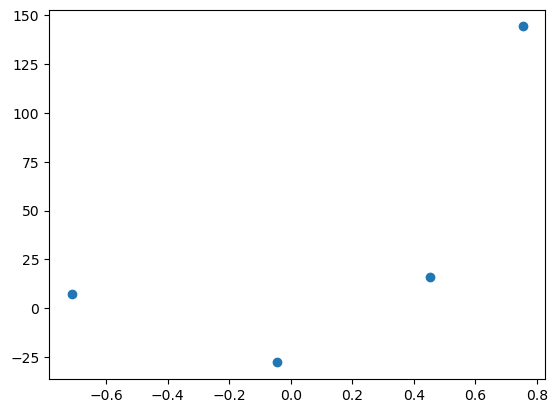

In [263]:
import matplotlib.pyplot as plt
plt.scatter(x,y)

In [264]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x,y)
print(lr.intercept_)
print(lr.coef_)

26.15963284313262
[78.35063668]


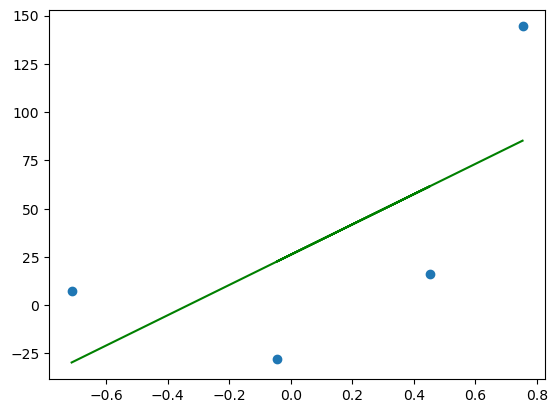

In [265]:
plt.scatter(x,y)
plt.plot(x,lr.predict(x),color='green')

In [266]:
# lets apply the gredient descent where m=78.35, b=0
y_pred =  ((78.35*x) + 0).reshape(4)
y_pred

array([-55.81580837,  35.39949674,  -3.48681619,  59.05759577])

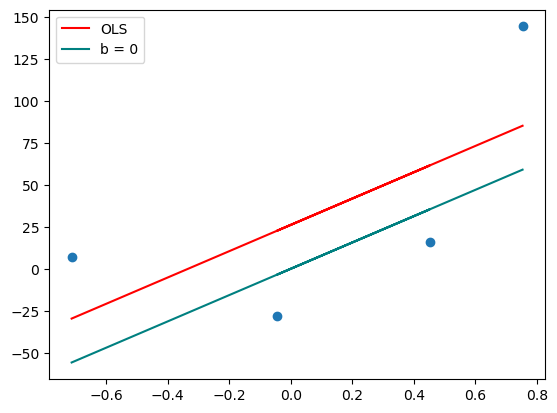

In [267]:
plt.scatter(x,y)
plt.plot(x,lr.predict(x),color='red',label='OLS')
plt.plot(x,y_pred,color='teal',label='b = 0')
plt.legend()
plt.show()

# calculating the gredient gradually

In [268]:
m = 78.35
b=1000
loss_slope = -2 * np.sum(y - m*x.ravel() - b)
loss_slope

np.float64(7790.722365917908)

In [269]:
# learning rate - it control the learning speed (a constant factor set by the developer or data scientist)
# Step Size: it is the size of steps we are taking towards the goal, with how much speed, our algorithm is learning(or approaching to the local minima)
LR = 0.1
step_size = LR*loss_slope
step_size

np.float64(779.0722365917909)

In [270]:
# calculating new intercept
b= b-step_size
b

np.float64(220.9277634082091)

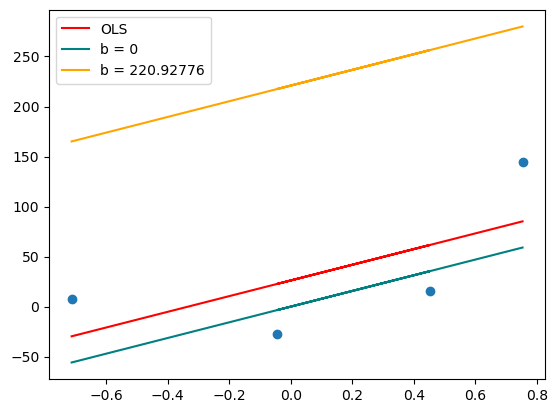

In [271]:
y_pred1 = (78.35*x + b).reshape(4)
plt.scatter(x,y)
plt.plot(x,lr.predict(x),color='red',label='OLS')
plt.plot(x,y_pred,color='teal',label='b = 0')
plt.plot(x,y_pred1,color='orange',label=f"""b = {b.round(5)}""")
plt.legend()
plt.show()

In [272]:
# iteration 2
loss_slope = -2 * np.sum(y - m*x.ravel() - b)
loss_slope

np.float64(1558.1444731835804)

In [273]:
step_size = LR*loss_slope
step_size

np.float64(155.81444731835805)

In [274]:
b = b - step_size
b

np.float64(65.11331608985105)

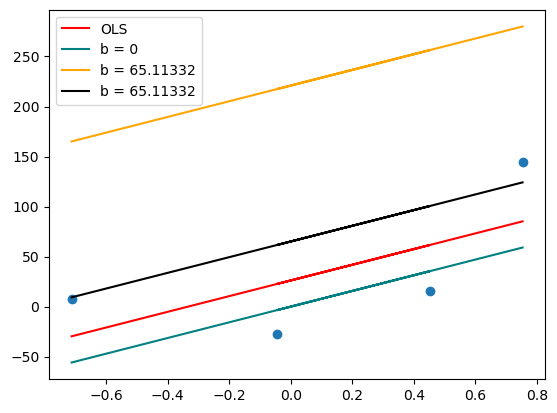

In [275]:
y_pred2 = (78.35*x + b).reshape(4)
plt.scatter(x,y)
plt.plot(x,lr.predict(x),color='red',label='OLS')
plt.plot(x,y_pred,color='teal',label='b = 0')
plt.plot(x,y_pred1,color='orange',label=f"""b = {b.round(5)}""")
plt.plot(x,y_pred2,color='black',label=f"""b = {b.round(5)}""")
plt.legend()
plt.show()

In [276]:
# iteration 3
loss_slope = -2 * np.sum(y - m*x.ravel() - b)
loss_slope

np.float64(311.62889463671627)

In [277]:
step_size = LR*loss_slope
step_size

np.float64(31.16288946367163)

In [278]:
b = b - step_size
b

np.float64(33.95042662617942)

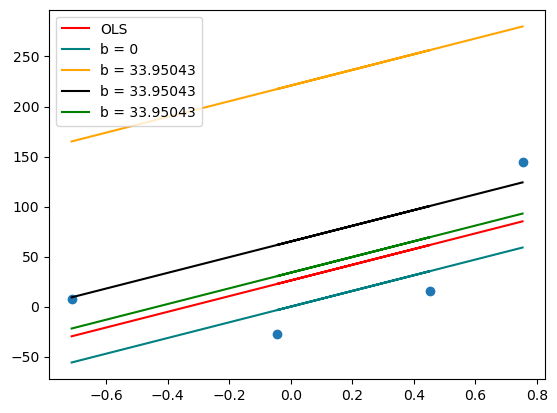

In [279]:
y_pred3 = (78.35*x + b).reshape(4)
plt.scatter(x,y)
plt.plot(x,lr.predict(x),color='red',label='OLS')
plt.plot(x,y_pred,color='teal',label='b = 0')
plt.plot(x,y_pred1,color='orange',label=f"""b = {b.round(5)}""")
plt.plot(x,y_pred2,color='black',label=f"""b = {b.round(5)}""")
plt.plot(x,y_pred3,color='green',label=f"""b = {b.round(5)}""")
plt.legend()
plt.show()

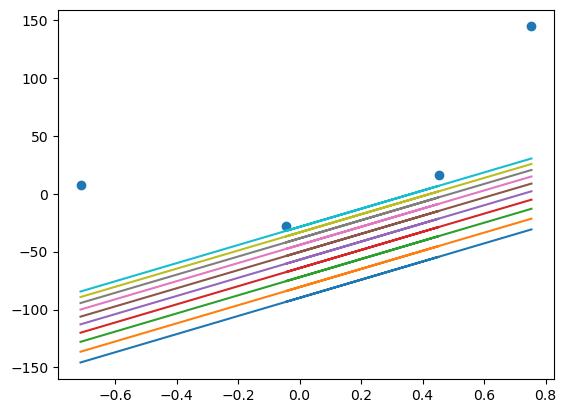

In [280]:
learning_rate = 0.01
m = 78.35
b = -100

epochs = 10
for i in range(epochs):
    loss_slope = -2 * np.sum(y - m*x.ravel() - b)
    step_size = learning_rate* loss_slope
    b = b - step_size

    y_pred = m*x + b
    plt.plot(x,y_pred)

plt.scatter(x,y)

# My Own custom class: with the constant m(slope-value)

In [281]:
from sklearn.datasets import make_regression
X,Y = make_regression(n_targets=1,n_features=1,n_samples=100,noise=20,random_state=3)

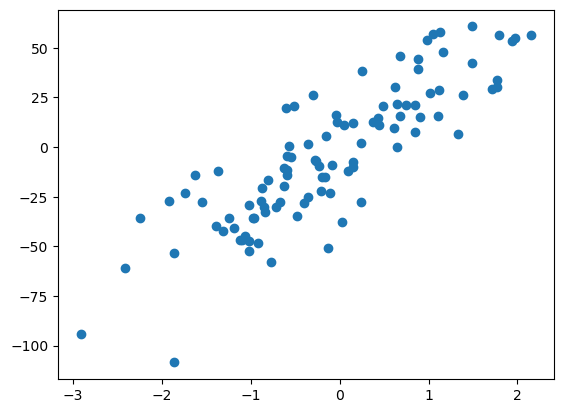

In [282]:
import matplotlib.pyplot as plt
import numpy as np

plt.scatter(X,Y)

In [283]:
from sklearn.linear_model import LinearRegression
Lr = LinearRegression()

Lr.fit(X,Y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


-1.1545329190125853
[27.73856274]


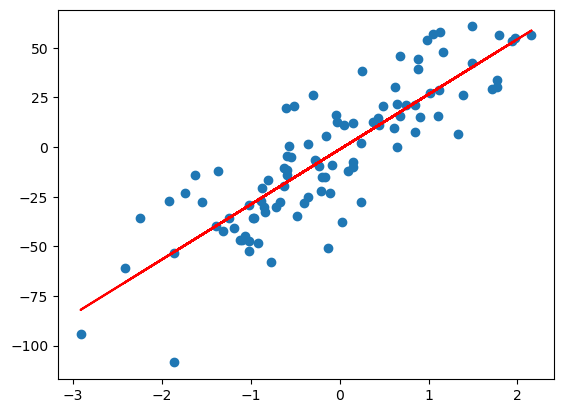

In [284]:
pred_y = Lr.predict(X)
plt.scatter(X,Y)
plt.plot(X,pred_y,color='red')
print(Lr.intercept_)
print(Lr.coef_)

In [285]:
class GDRegressor:
    def __init__(self,epochs,lr):
        self.b = -120
        self.lr = lr
        self.epochs = epochs
        self.m = 27.73856274
    def fit(self,X,Y):
        for i in range(self.epochs):
            loss_slope = -2 * np.sum(Y - self.m*X.ravel() - self.b)
            step_size = loss_slope*self.lr
            self.b = self.b - step_size
            print(self.b)
            
        print(self.b)

    def predict(self):
        return self.m * X + self.b
            

In [286]:
myGDR = GDRegressor(100,0.001)
myGDR.fit(X,Y)

-96.23090658387095
-77.2156318509677
-62.003412064645104
-49.83363623558703
-40.097815572340565
-32.30915904174339
-26.078233817265655
-21.09349363768347
-17.10570149401772
-13.91546777908512
-11.363280807139038
-9.321531229582174
-7.688131567536683
-6.38141183790029
-5.336036054191176
-4.499735427223884
-3.830694925650051
-3.2954625243909845
-2.8672766033837314
-2.524727866577929
-2.2506888771332867
-2.031457685577573
-1.8560727323330022
-1.7157647697373455
-1.60351839966082
-1.5137213035995998
-1.4418836267506236
-1.3844134852714427
-1.338437372088098
-1.3016564815414222
-1.2722317691040816
-1.2486919991542091
-1.229860183194311
-1.2147947304263926
-1.202742368212058
-1.1931004784405903
-1.185386966623416
-1.1792161571696766
-1.1742795096066851
-1.170330191556292
-1.1671707371159774
-1.1646431735637257
-1.1626211227219243
-1.1610034820484831
-1.1597093695097302
-1.158674079478728
-1.1578458474539262
-1.1571832618340847
-1.1566531933382116
-1.1562291385415129
-1.155889894704154
-1.155

# My Own custom class: with both values with vaiable

In [297]:
from sklearn.datasets import make_regression
X,Y = make_regression(n_targets=1,n_features=1,n_samples=100,noise=20,random_state=3)

from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,random_state=3,test_size = 0.2)

In [315]:
class GDR:
    def __init__(self,learning_rate,epochs):
        self.b = 100
        self.m = -120
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self,X_train,Y_train):
        for i in range(self.epochs):
            loss_slope_b = -2 * np.sum(Y_train - self.m *X_train.ravel() - self.b)
            loss_slope_m = -2 * np.sum((Y_train - self.m *X_train.ravel() - self.b)*X_train.ravel())

            self.b = self.b - (self.lr * loss_slope_b)
            self.m = self.m - (self.lr * loss_slope_m)
        print(f"""b: {self.b}\nm: {self.m}""")

    def predict(self,X_test):
        return self.m * X_test + self.b


In [ ]:
myLR = GDR(0.001,50000)

In [346]:
myLR.fit(X,Y)

b: -1.1545329190125841
m: 27.73856274314933


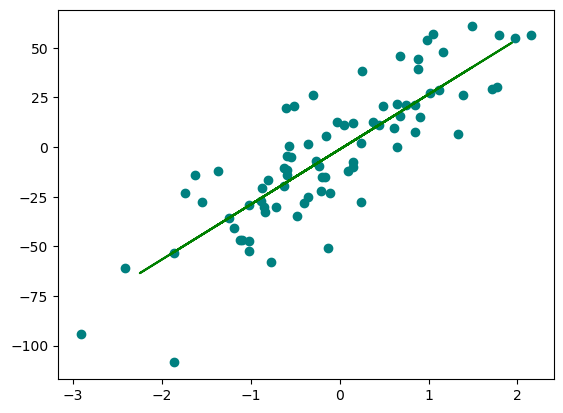

In [347]:
predd = myLR.predict(X_test)
plt.scatter(X_train,Y_train,color="teal")
plt.plot(X_test,predd,color='green')

In [292]:
from sklearn.linear_model import LinearRegression
l = LinearRegression()

In [293]:
l.fit(X,Y)
pred = l.predict(X_test)

In [294]:
print("b: ",lr.intercept_) #b

b:  26.15963284313262


In [295]:
print("m: ",lr.coef_) #m

m:  [78.35063668]


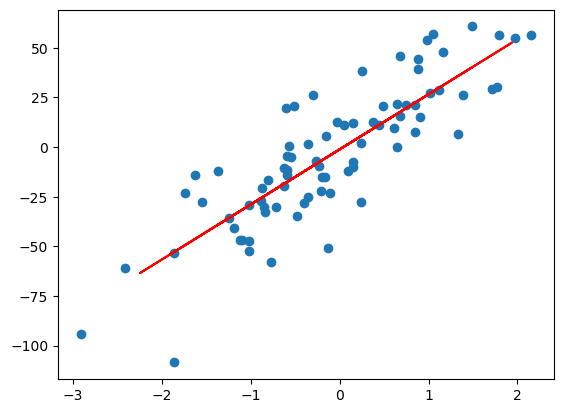

In [296]:
plt.scatter(X_train,Y_train)
plt.plot(X_test,pred,color='red')